In [2]:
#Imports and data loading

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import torchvision.utils as vutils
from preprocessing import get_celeba_dataloaders

sns.set_theme(style="whitegrid")
%matplotlib inline

data_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(f"Dataset location: {data_path}")

attr_df = pd.read_csv(os.path.join(data_path, "list_attr_celeba.csv"))
partition_df = pd.read_csv(os.path.join(data_path, "list_eval_partition.csv"))

attr_df = attr_df.replace(-1, 0)

Dataset location: C:\Users\aniak\.cache\kagglehub\datasets\jessicali9530\celeba-dataset\versions\2


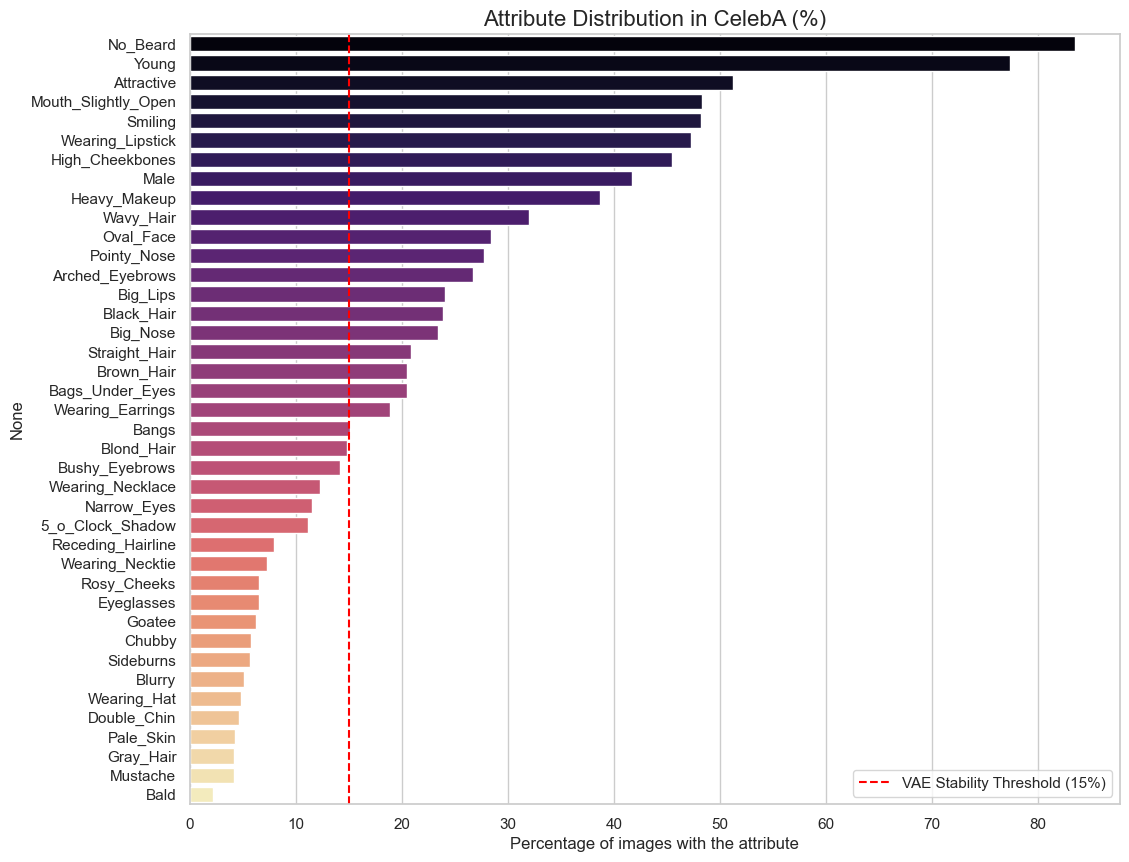

In [3]:
# Attribute distribution analysis

attr_counts = attr_df.drop('image_id', axis=1).mean() * 100
attr_counts = attr_counts.sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x=attr_counts.values, y=attr_counts.index, hue=attr_counts.index, palette="magma", legend=False)
plt.title("Attribute Distribution in CelebA (%)", fontsize=16)
plt.xlabel("Percentage of images with the attribute", fontsize=12)
plt.axvline(x=15, color='red', linestyle='--', label='VAE Stability Threshold (15%)')
plt.legend()
plt.show()

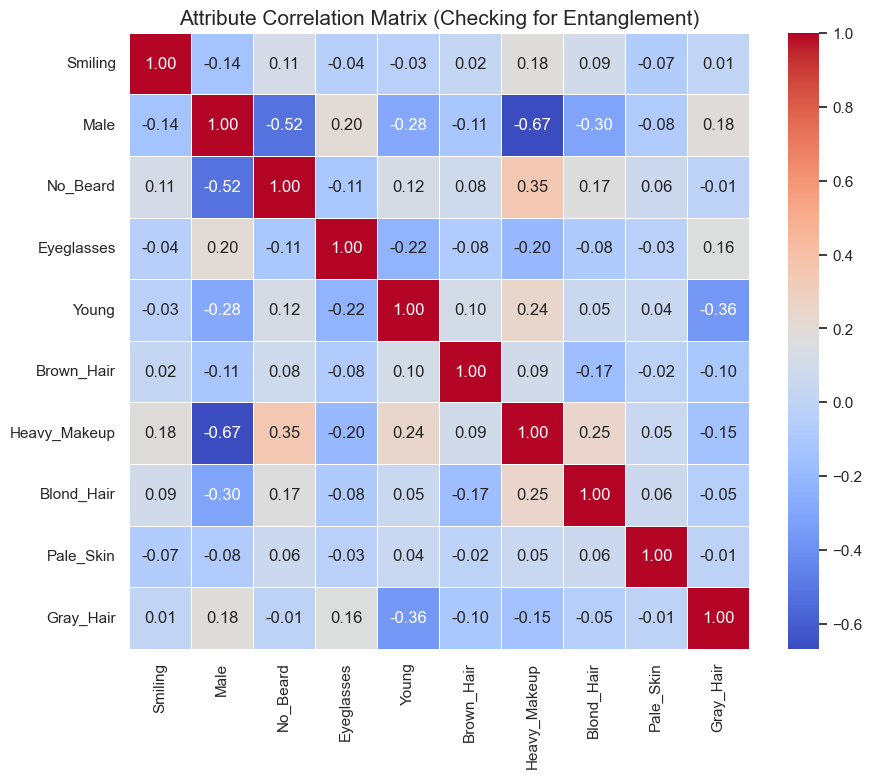

In [10]:
# Feature correlation analysis

target_features = ['Smiling', 'Male', 'No_Beard', 'Eyeglasses', 'Young', 
                   'Brown_Hair', 'Heavy_Makeup', 'Blond_Hair', 'Pale_Skin', 'Gray_Hair']

correlation_matrix = attr_df[target_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Attribute Correlation Matrix (Checking for Entanglement)", fontsize=15)
plt.show()

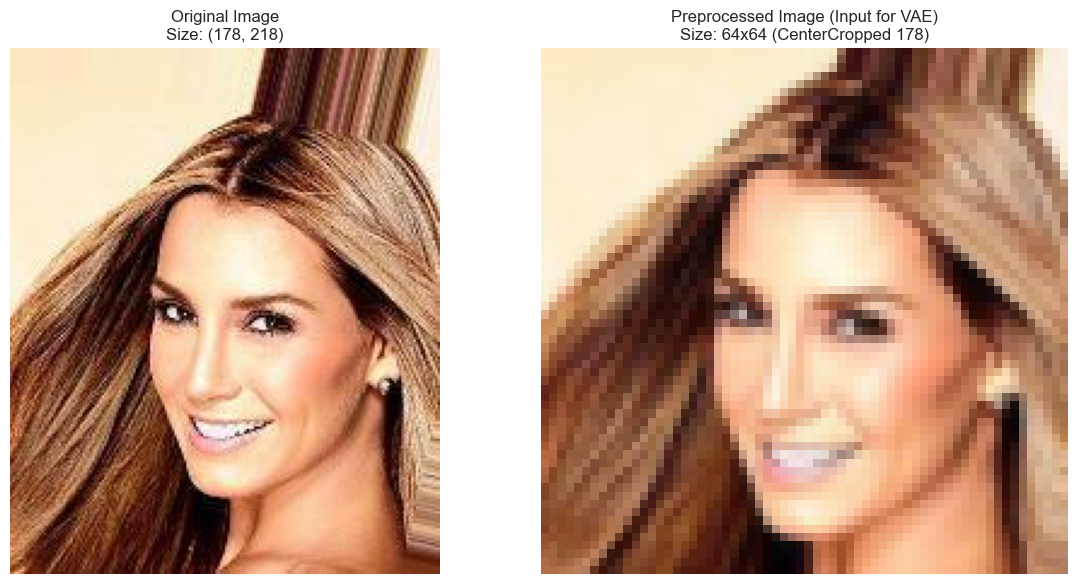

In [7]:
# Original vs Preprocessed - comparison

from PIL import Image
from preprocessing import get_celeba_dataloaders, get_transforms

sample_img_name = attr_df.iloc[0]['image_id']
raw_img_path = os.path.join(data_path, "img_align_celeba", "img_align_celeba", sample_img_name)

raw_image = Image.open(raw_img_path)

preprocess = get_transforms(img_size=64)
preprocessed_image = preprocess(raw_image)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(raw_image)
axes[0].set_title(f"Original Image\nSize: {raw_image.size}", fontsize=12)
axes[0].axis('off')

axes[1].imshow(np.transpose(preprocessed_image.numpy(), (1, 2, 0)))
axes[1].set_title(f"Preprocessed Image (Input for VAE)\nSize: 64x64 (CenterCropped 178)", fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# Preparing Indices for all Target Features
import json

target_features = [
    'Smiling', 'Male', 'No_Beard', 'Eyeglasses', 'Young', 
    'Brown_Hair', 'Heavy_Makeup', 'Blond_Hair', 'Pale_Skin', 'Gray_Hair'
]

def get_clean_indices(df, feature_name, n_samples=500):
    pos_indices = df[df[feature_name] == 1].head(n_samples).index.tolist()
    neg_indices = df[df[feature_name] == 0].head(n_samples).index.tolist()
    return pos_indices, neg_indices

latent_manipulation_map = {}

for feature in target_features:
    pos, neg = get_clean_indices(attr_df, feature)
    latent_manipulation_map[feature] = {
        'pos': pos,
        'neg': neg
    }
    print(f"Indices for '{feature}' collected (Pos: {len(pos)}, Neg: {len(neg)})")

with open('latent_manipulation_map.json', 'w') as f:
    json.dump(latent_manipulation_map, f, indent=4)

print("\nSuccess! Full latent manipulation map saved to 'latent_manipulation_map.json'")


Indices for 'Smiling' collected (Pos: 500, Neg: 500)
Indices for 'Male' collected (Pos: 500, Neg: 500)
Indices for 'No_Beard' collected (Pos: 500, Neg: 500)
Indices for 'Eyeglasses' collected (Pos: 500, Neg: 500)
Indices for 'Young' collected (Pos: 500, Neg: 500)
Indices for 'Brown_Hair' collected (Pos: 500, Neg: 500)
Indices for 'Heavy_Makeup' collected (Pos: 500, Neg: 500)
Indices for 'Blond_Hair' collected (Pos: 500, Neg: 500)
Indices for 'Pale_Skin' collected (Pos: 500, Neg: 500)
Indices for 'Gray_Hair' collected (Pos: 500, Neg: 500)

Success! Full latent manipulation map saved to 'latent_manipulation_map.json'
